In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score


In [11]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [14]:
X=data[['AveRooms']].values
y=data['Price'].values

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.8,random_state=42)

In [73]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [74]:
w=0
b=0
learning_rate=0.01

epochs=1000
cost_history=[]
n=len(X_train_scaled)

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    cost=(1/(2*n)*np.sum((y_pred -y_train) ** 2))
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b= b - learning_rate * db
    if i % 100 ==0:
        
        print(f"Epoch {i},Cost ={cost:.4f}")
y_pred_gd =w * X_test_scaled.flatten() + b 
    

Epoch 0,Cost =2.8193
Epoch 100,Cost =0.9492
Epoch 200,Cost =0.6986
Epoch 300,Cost =0.6650
Epoch 400,Cost =0.6605
Epoch 500,Cost =0.6599
Epoch 600,Cost =0.6599
Epoch 700,Cost =0.6598
Epoch 800,Cost =0.6598
Epoch 900,Cost =0.6598


In [75]:
print("Gradient Descent")
print("----------------")
print("Weight:",w)
print("Bias",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 Score",r2_score(y_test,y_pred_gd))



Gradient Descent
----------------
Weight: 0.1622011552292036
Bias 2.071766165873958
MSE: 1.2988602093824142
R2 Score 0.02189668273544154


In [76]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]
theta = np.linalg.inv(X_train_ne.T @ X_train_ne )@ X_train_ne.T@ y_train
y_pred_ne =X_test_ne @ theta


In [77]:
print("Normal Eqution")
print("----------------")
print("Weight:",theta[1])
print("Bias",theta[0])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score",r2_score(y_test,y_pred_ne))


Normal Eqution
----------------
Weight: 0.051844714648327385
Bias 1.7877830289254806
MSE: 1.2988597038335623
R2 Score 0.021897063437695374


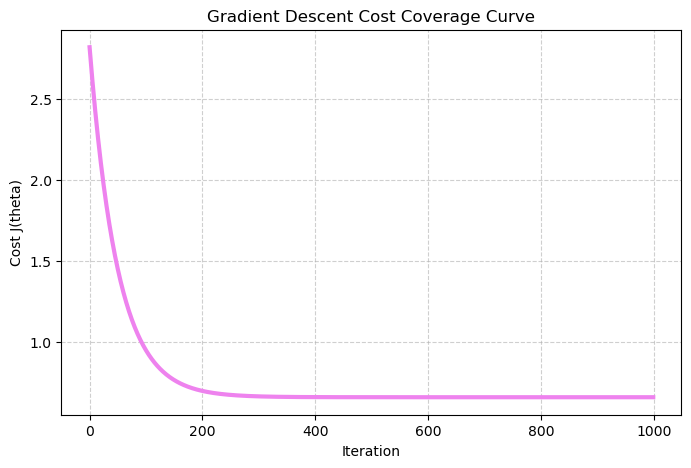

In [87]:
plt.figure(figsize=(8,5))

plt.plot(cost_history,color='violet',linewidth=3)

plt.title('Gradient Descent Cost Coverage Curve')

plt.xlabel('Iteration')

plt.ylabel('Cost J(theta)')

plt.grid(True,linestyle='--',alpha=0.6)

plt.show()


NameError: name 'test' is not defined

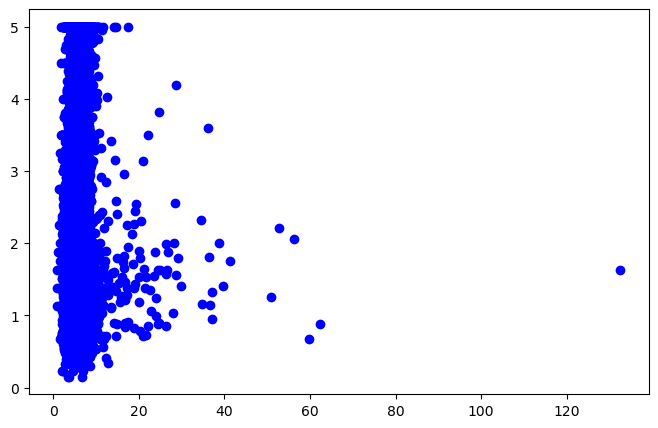

In [88]:
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(X-test.flatten()[index],y_pred_ne[index],color='violet',linewidth=3,label='Regression Line')
plt.title('Linear Regression')

plt.xlabel('Average rooms')

plt.ylabel('Median house value')
plt.legend()

plt.grid(True)

plt.show()

